In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models 
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [2]:
import sys

print(sys.executable)
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_gpu_available())

c:\dev\Projects\Crop_Disease_Detector\.venv\Scripts\python.exe
2.10.1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
True


In [3]:
# https://www.kaggle.com/datasets/arjuntejaswi/plant-village?resource=download

IMAGE_SIZE = 256
BATCH_SIZE = 32
RGB_CHANNELS = 3
DATA_DIR = Path.cwd().parent / 'data' / 'potato'


dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR, 
    shuffle=True, 
    image_size=(IMAGE_SIZE, IMAGE_SIZE), 
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [5]:
# 20638 files/images divided into 32 batch size ~= 644 batches
len(dataset) 

68

In [6]:
# image_batch is a tensor of shape (32, 256, 256, 3) -> (batch_size, height, width, channels)
# label_batch is a tensor of shape (32,) -> (batch_size,)
# 15 classes in total, so label_batch contains integers from 0 to 14 representing the class indices.
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())


(32, 256, 256, 3)
[1 2 1 0 0 0 0 0 0 0 1 1 2 0 0 1 1 1 2 1 1 0 1 1 0 1 2 1 0 2 0 1]


In [7]:
for i in dataset.take(1):
    print(i[0].shape)

(32, 256, 256, 3)


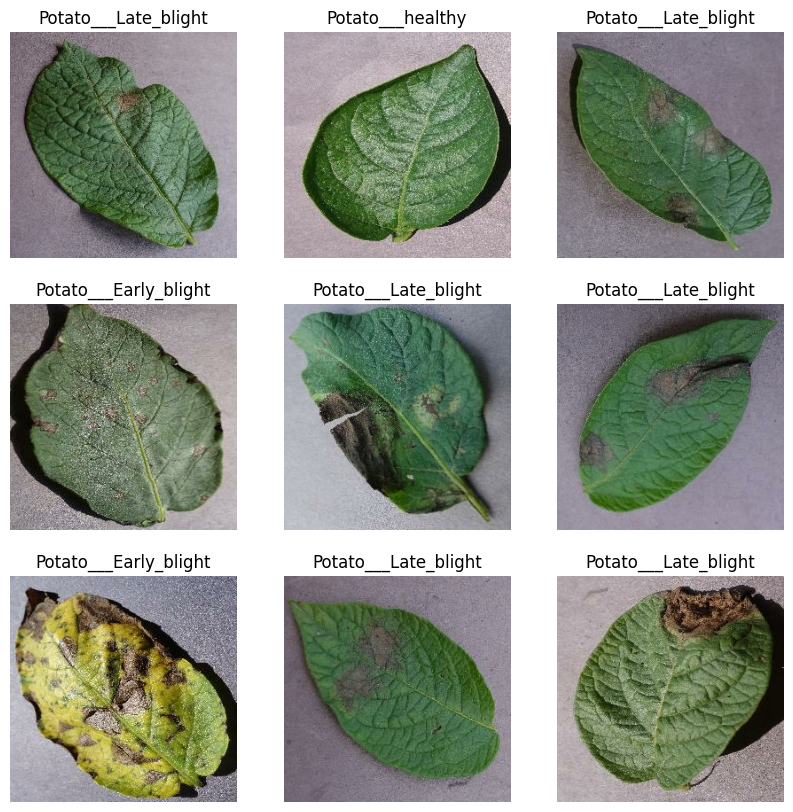

In [8]:
plt.figure(figsize=(10, 10))

for image_batch, label_batch in dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis('off')
        plt.title(class_names[label_batch[i]])

# Train Test Split

In [9]:
# 80 percent training, 10 percent validation, 10 percent test
EPOCHS = 50
train_size = 0.8 

In [10]:
def get_dataset_partitions_tf(ds: tf.data.Dataset, 
                              train_split:float=0.8, 
                              val_split:float=0.1, 
                              test_split:float=0.1, 
                              shuffle:bool=True, shuffle_size:int=10000) -> tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset]:

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(ds_size * train_split)
    val_size = int(ds_size * val_split)
    test_size = int(ds_size * test_split)

    train_ds = ds.take(train_size)
    validation_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size).take(test_size)

    return train_ds, validation_ds, test_ds

In [11]:
train_ds, validation_ds, test_ds = get_dataset_partitions_tf(dataset)

In [12]:
len(train_ds), len(validation_ds), len(test_ds)

(54, 6, 6)

# Scaling

In [13]:
resize_rescale_pipeline = models.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE), # Resize images just in case they are not already 256x256
    layers.Rescaling(1/255), # Scale RGB pixel values to 0,1
])

# Data Augmentation

In [14]:
data_augmentation_pipeline = models.Sequential([
    # Create slightly different versions of each image during training\n",
    # so the model learns features that generalize better.\n",
    layers.RandomFlip('horizontal_and_vertical'),  # Flip leaves in either direction.
    layers.RandomRotation(0.1),  # Small rotations help with camera angle variation.
    layers.RandomZoom(0.1),  # Small zoom changes help with distance/cropping variation
    layers.RandomContrast(0.1)  # Small contrast changes help with lighting variation
    
])

# Optimizing dataset with cache and prefetch

In [ ]:
train_ds = train_ds.cache()
# Include data augmentation in the training pipeline so model executes quicker during training, but not validation or test pipelines.
train_ds = train_ds.map(
    lambda x, y: (data_augmentation_pipeline(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).shuffle(1000).prefetch(tf.data.AUTOTUNE)

validation_ds = validation_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

# CNN

In [16]:
# Input shape
print(next(iter(dataset.take(1)))[0].shape)

(32, 256, 256, 3)


In [17]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, RGB_CHANNELS)

# Convolution and Pooling Layers -> Dense NN
# filters = how many different feature patterns this layer learns to detect.
# kernel_size = the height and width of the sliding window used to scan the image.
# pool_size = the size of the window (for example 2x2) that downsamples the feature map while keeping the strongest features.
model = models.Sequential([
    layers.Input(shape=input_shape),
    resize_rescale_pipeline,
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

In [18]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 64)       

In [19]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), # Since we use softmax activation in the output layer, we set from_logits=False. If we had no activation or used linear activation, we would set from_logits=True.
    metrics=['accuracy']
)

In [20]:
model_history = model.fit(train_ds,
          epochs=EPOCHS,
          batch_size=BATCH_SIZE,
          verbose=1,
          validation_data=validation_ds
)

Epoch 1/50
54/54 [==============================] - 10s 80ms/step - loss: 0.8407 - accuracy: 0.5411 - val_loss: 0.4728 - val_accuracy: 0.8177
Epoch 2/50
54/54 [==============================] - 4s 62ms/step - loss: 0.3973 - accuracy: 0.8345 - val_loss: 0.4349 - val_accuracy: 0.8281
Epoch 3/50
54/54 [==============================] - 4s 63ms/step - loss: 0.2640 - accuracy: 0.8926 - val_loss: 0.3108 - val_accuracy: 0.8906
Epoch 4/50
54/54 [==============================] - 4s 62ms/step - loss: 0.2735 - accuracy: 0.8862 - val_loss: 0.2444 - val_accuracy: 0.9323
Epoch 5/50
54/54 [==============================] - 4s 62ms/step - loss: 0.2334 - accuracy: 0.9067 - val_loss: 0.2272 - val_accuracy: 0.9010
Epoch 6/50
54/54 [==============================] - 4s 62ms/step - loss: 0.1666 - accuracy: 0.9396 - val_loss: 0.1788 - val_accuracy: 0.9323
Epoch 7/50
54/54 [==============================] - 4s 61ms/step - loss: 0.1569 - accuracy: 0.9372 - val_loss: 0.2793 - val_accuracy: 0.9219
Epoch 8/50
5

In [21]:
scores = model.evaluate(test_ds)

6/6 [==============================] - 1s 19ms/step - loss: 0.0491 - accuracy: 0.9762


In [22]:
scores

[0.04914524406194687, 0.976190447807312]

In [24]:
model_history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [25]:
model_history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [27]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

Text(0.5, 1.0, 'Model Loss')

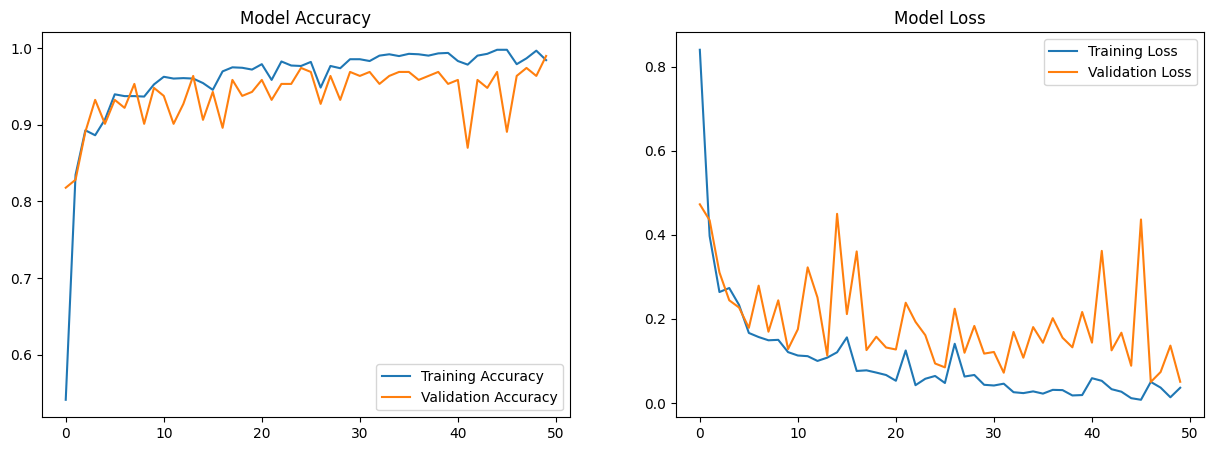

In [31]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend()
plt.title('Model Loss')

Actual Label: Potato___Early_blight
1/1 [==============================] - 0s 24ms/step

Predicted Label: Potato___Early_blight
[9.9998391e-01 1.5344729e-05 7.6481024e-07]


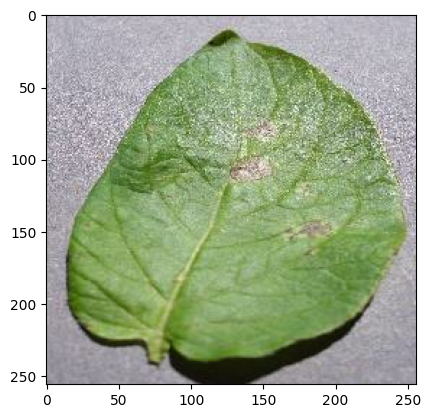

In [43]:
for image_batch, label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    first_label = label_batch[0].numpy()

    print('Actual Label:', class_names[first_label])
    plt.imshow(first_image)

    batch_predictions = model.predict(image_batch)
    print('\nPredicted Label:', class_names[batch_predictions[0].argmax()])
    print(batch_predictions[0])

In [59]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img.numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[predictions[0].argmax()]
    confidence = round(100 * (predictions[0].max()), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 14ms/step


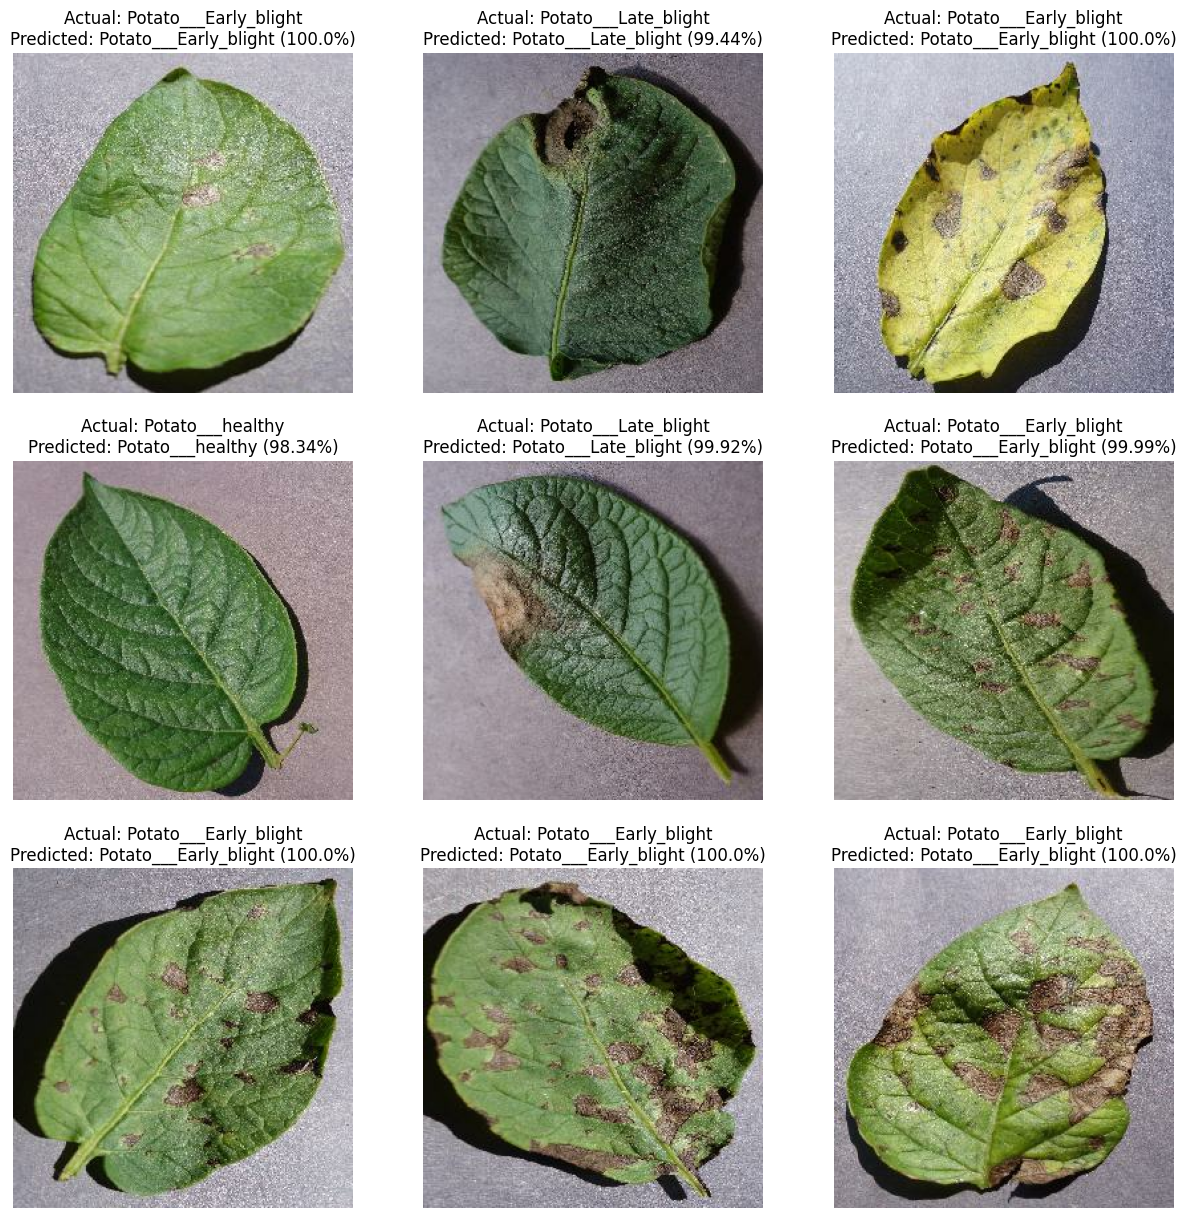

In [60]:

plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
    for i in range(9):
        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[labels[i].numpy()]

        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f'Actual: {actual_class}\nPredicted: {predicted_class} ({confidence}%)')
        plt.axis('off')

In [62]:
model_version = 1 
model.save(f'models/potato_disease_model_v{model_version}')

INFO:tensorflow:Assets written to: models/potato_disease_model_v1\assets


INFO:tensorflow:Assets written to: models/potato_disease_model_v1\assets
